# Live demo - Surface to local vol to PDE dashboard

This notebook is a **capstone walkthrough** of an end-to-end workflow:

**synthetic quotes → implied surface → (repair-aware) local vol → PDE pricing**, with diagnostics at each step.

> Why this matters: local-vol pipelines are numerically fragile (they depend on derivatives of the surface), so the project is built around **stability, validation, and failure-mode visibility**.

- **Quick mode (default):** minimal outputs, runs fast.
- **Full mode:** adds deeper diagnostics / sweeps for presentations and deep-dives.

For a short presentation script, see: `docs/user_guides/flagship_capstone2_page.md`.

<details>
<summary><b>Speaker notes (15–25s)</b></summary>

- Punchline: “Surface → Local vol (with explicit diagnostics) → PDE pricing (with convergence evidence).”
- Emphasize: the differentiations make this fragile, so guardrails matter.

</details>


## What this demo demonstrates

1. **Pipeline completeness**: quotes → implied surface → local vol → PDE pricing.
2. **Numerical judgment**: diagnostics are first-class outputs (not hidden internals).
3. **Surface craft**: fit quality + repair-awareness so downstream differentiation is feasible.
4. **PDE credibility**: baseline checks + refinement/convergence evidence.

Tip: run the notebook in **quick** mode first. Switch to **full** mode only when you want the extra sweeps / deep diagnostics.


In [1]:
# --- imports ---
from option_pricing.diagnostics.vol_surface import plot as vs_plot

In [2]:
# --- demo dashboard (Quick/Full toggle + cached run) ---
from option_pricing.demos import DemoDashboard

demo = DemoDashboard()
demo.display()

ensure_art = demo.ensure_art
show_table = demo.show_table

Output()

Output()

## Live demo workflow

- Start in **Quick** → click **Run pipeline** once, then run the narrative cells below (they will reuse `art`).
- Switch to **Full** only when you want deeper diagnostics/sweeps → click **Run pipeline** again.
- If you change **Profile** or **Seed**, click **Apply** (and rerun the pipeline if you want updated results).


## 1) Build synthetic market quotes (with controlled noise / outliers)

**Intent:** generate “market-like” quotes where the **latent truth is no-arbitrage**, while observed quotes may be noisy.  
**Takeaway:** any downstream instability you see is a numerics/interpolation story, not a broken ground truth.

<details>
<summary><b>Speaker notes (15–20s)</b></summary>

- “This gives us a controlled dataset: true surface is sane; observed quotes can be messy.”
- “That lets us focus on stability and diagnostics.”

</details>


In [5]:
# --- Synthetic data build with latent no-arb validation / auto-tuning ---

art = ensure_art(force=False)
quotes_df = art.synthetic["quotes_df"]

# Keep the quick path focused:
show_table("Quote sample", art.tables.get("quotes_df"), max_rows=12)
show_table("Quote summary by expiry", art.tables.get("quote_summary"), max_rows=12)

# One important credibility check: latent truth is no-arb (small table; safe to show in quick).
show_table("Latent truth no-arb check (benchmark surface)", art.tables.get("latent_truth_noarb"), max_rows=12)

# Optional deeper setup diagnostics (full mode only)
if demo.SHOW_ADVANCED:
    show_table("Latent-truth no-arb tuning log (auto-check)", art.tables.get("synth_tuning_log"), max_rows=10)
    show_table("Synthetic config actually used", art.tables.get("synth_cfg_used"), max_rows=50)


### Quote sample

,T,x,K,F,iv_obs,iv_true,y,w_obs,w_true,iv_noise_bp
0,0.1,-0.30,74.230134,100.2002,0.344461,0.344460,-0.30,0.011865,0.011865,0.012302
1,0.1,-0.28,75.729682,100.2002,0.334451,0.334152,-0.28,0.011186,0.011166,2.987455
2,0.1,-0.26,77.259523,100.2002,0.323493,0.323767,-0.26,0.010465,0.010482,-2.741379
3,0.1,-0.24,78.820269,100.2002,0.312439,0.313330,-0.24,0.009762,0.009818,-8.905918
4,0.1,-0.22,80.412544,100.2002,0.302420,0.302875,-0.22,0.009146,0.009173,-4.546708
5,0.1,-0.20,82.036985,100.2002,0.291453,0.292445,-0.20,0.008495,0.008552,-9.916466
6,0.1,-0.18,83.694242,100.2002,0.282156,0.282096,-0.18,0.007961,0.007958,0.601436
7,0.1,-0.16,85.384978,100.2002,0.273235,0.271894,-0.16,0.007466,0.007393,13.402152
8,0.1,-0.14,87.109869,100.2002,0.261432,0.261924,-0.14,0.006835,0.006860,-4.922065
9,0.1,-0.12,88.869605,100.2002,0.251663,0.252283,-0.12,0.006333,0.006365,-6.204749


_Showing first 12 of 341 rows. Toggle `Verbose tables` to show full tables._

### Quote summary by expiry

,T,n_quotes,iv_obs_min,iv_obs_max,mean_abs_noise_bp
0,0.10,31,0.198002,0.344461,7.009819
1,0.15,31,0.205030,0.308949,6.692462
2,0.20,31,0.210328,0.291483,6.351922
3,0.25,31,0.213555,0.281815,6.985789
4,0.33,31,0.219184,0.270194,7.475755
5,0.50,31,0.228081,0.263668,6.752014
6,0.75,31,0.238333,0.264497,9.015742
7,1.00,31,0.247110,0.266082,7.183411
8,1.25,31,0.254239,0.268964,8.603609
9,1.50,31,0.261457,0.273378,6.262839


...

,latent_truth_ok,message,calendar_ok,calendar_max_violation
0,True,"OK, mono_bad=0/11, butterfly_bad=0/11, calenda...",True,0.0


### Latent-truth no-arb tuning log (auto-check)

,round,model,ok,message,atm_level,atm_term_slope,b_level,b_term_slope,rho,m_level,sigma_level,sigma_term_slope
0,0,svi,True,"OK, mono_bad=0/11, butterfly_bad=0/11, calenda...",0.2,0.045,0.03,0.006,-0.35,-0.015,0.24,0.02


### Synthetic config actually used

,spot,r,q,expiries,x_grid,model,atm_level,atm_term_slope,atm_term_ref,b_level,...,sigma_level,sigma_term_slope,noise_mode,noise_level,noise_dist,noise_smooth_window,outlier_prob,outlier_scale,missing_prob,seed
0,100.0,0.02,0.0,"(0.1, 0.15, 0.2, 0.25, 0.33, 0.5, 0.75, 1.0, 1...","[-0.3, -0.27999999999999997, -0.26, -0.24, -0....",svi,0.2,0.045,0.5,0.03,...,0.24,0.02,absolute,0.001,normal,1,0.0,4.0,0.0,7


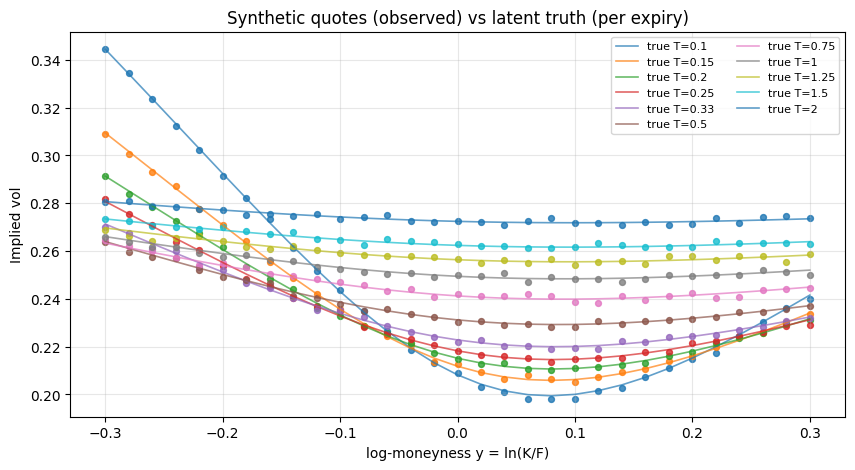

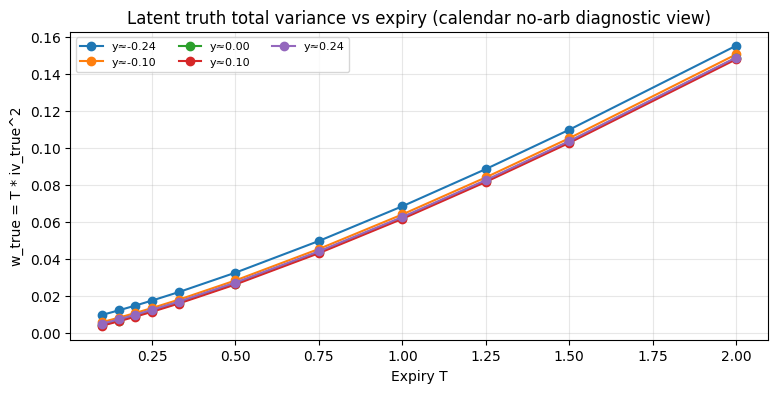

In [6]:
# Visual check: observed vs true IV smile per expiry
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
for T, g in quotes_df.groupby("T", sort=True):
    ax.plot(g["y"], g["iv_true"], linewidth=1.2, alpha=0.7, label=f"true T={T:g}")
    ax.scatter(g["y"], g["iv_obs"], s=18, alpha=0.8)

ax.set_title("Synthetic quotes (observed) vs latent truth (per expiry)")
ax.set_xlabel("log-moneyness y = ln(K/F)")
ax.set_ylabel("Implied vol")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.show()

# IMPORTANT: IV lines crossing across maturities does NOT imply calendar arbitrage.
# Calendar no-arb is about total variance w(T,y)=T*iv^2 being non-decreasing in T at fixed y.
fig, ax = plt.subplots(figsize=(9, 4))
y_targets = [-0.25, -0.10, 0.00, 0.10, 0.25]
y_unique = np.sort(quotes_df["y"].unique())
for y0 in y_targets:
    y_pick = float(y_unique[np.argmin(np.abs(y_unique - y0))])
    g = quotes_df[np.isclose(quotes_df["y"], y_pick)].sort_values("T")
    if g.shape[0] >= 2:
        ax.plot(g["T"], g["w_true"], marker="o", label=f"y≈{y_pick:.2f}")

ax.set_title("Latent truth total variance vs expiry (calendar no-arb diagnostic view)")
ax.set_xlabel("Expiry T")
ax.set_ylabel("w_true = T * iv_true^2")
ax.grid(True, alpha=0.3)
ax.legend(ncol=3, fontsize=8)
plt.show()

## 2) Build implied surfaces: raw grid vs SVI (repair-aware)

**Message:** the right question is not “can I fit it?” but **“can I safely differentiate it?”**  
We compare a direct grid construction to an SVI-based surface, and (when needed) a repair-aware variant.

<details>
<summary><b>Speaker notes (20–30s)</b></summary>

- “Raw quotes can violate no-arb and are not reliably differentiable.”
- “SVI gives structure; repair-awareness makes the surface safer for local-vol extraction.”

</details>


In [7]:
# Surfaces built by the capstone runner
surface_true_grid = art.surfaces["true_grid"]
surface_grid = art.surfaces["grid"]
surface_svi_norepair = art.surfaces["svi_norepair"]
surface_svi_repaired = art.surfaces["svi_repaired"]

# In quick mode, keep this lightweight; in full mode, show the attempts table.
print("Selected repaired SVI mode:", art.meta.get("svi_repair_mode_used", "<unknown>"))
if demo.SHOW_ADVANCED:
    show_table("Repaired SVI build attempts", art.tables.get("svi_repair_attempts"), max_rows=10)

# Compact “what we built” summary
try:
    import pandas as pd
    items = [
        ("true_grid (latent)", len(surface_true_grid.smiles)),
        ("grid (from quotes)", len(surface_grid.smiles)),
        ("SVI repaired", len(surface_svi_repaired.smiles)),
    ]
    if demo.SHOW_ADVANCED:
        items.insert(2, ("SVI no-repair", len(surface_svi_norepair.smiles)))
    show_table("Built surface variants", pd.DataFrame(items, columns=["surface", "n_smiles"]), max_rows=10)
except Exception:
    pass


Selected repaired SVI mode: robust_all_line_search


### Repaired SVI build attempts

,label,ok,error
0,robust_all_line_search,True,


### Built surface variants

,surface,n_smiles
0,true_grid (latent),11
1,grid (from quotes),11
2,SVI no-repair,11
3,SVI repaired,11


In [8]:
# Diagnostics: why a repair candidate failed (full mode only)
if demo.SHOW_ADVANCED:
    import pandas as pd

    show_table("SVI repair attempts", art.tables.get("svi_repair_attempts"), max_rows=12)
    show_table("Synthetic config used", art.tables.get("synth_cfg_used"), max_rows=30)

    # Per-expiry SVI diagnostics (no-repair) if available
    df_nr = art.tables.get("svi_fit_norepair")
    if df_nr is not None and hasattr(df_nr, "empty") and (not df_nr.empty):
        cols = [
            "T","rmse_w","max_abs_werr","butterfly_ok","min_g","butterfly_reason",
            "b_large","b_blown_up","rho_near_pm1","sigma_tiny","m_outside_data",
        ]
        cols = [c for c in cols if c in df_nr.columns]
        show_table("Per-expiry SVI diagnostics (no-repair)", df_nr[cols].sort_values("T").reset_index(drop=True), max_rows=12)

    # If repaired diagnostics are available, compare butterfly outcomes
    df_fx = art.tables.get("svi_fit_repaired")
    if df_fx is not None and hasattr(df_fx, "empty") and (not df_fx.empty):
        cols_fx = [
            "T","butterfly_ok","min_g","butterfly_reason","b_large","b_blown_up",
            "rho_near_pm1","sigma_tiny","m_outside_data",
        ]
        cols_fx = [c for c in cols_fx if c in df_fx.columns]
        show_table("Per-expiry SVI diagnostics (repaired)", df_fx[cols_fx].sort_values("T").reset_index(drop=True), max_rows=12)


### SVI repair attempts

,label,ok,error
0,robust_all_line_search,True,


### Synthetic config used

,spot,r,q,expiries,x_grid,model,atm_level,atm_term_slope,atm_term_ref,b_level,...,sigma_level,sigma_term_slope,noise_mode,noise_level,noise_dist,noise_smooth_window,outlier_prob,outlier_scale,missing_prob,seed
0,100.0,0.02,0.0,"(0.1, 0.15, 0.2, 0.25, 0.33, 0.5, 0.75, 1.0, 1...","[-0.3, -0.27999999999999997, -0.26, -0.24, -0....",svi,0.2,0.045,0.5,0.03,...,0.24,0.02,absolute,0.001,normal,1,0.0,4.0,0.0,7


### Per-expiry SVI diagnostics (no-repair)

,T,rmse_w,max_abs_werr,butterfly_ok,min_g,butterfly_reason,b_large,b_blown_up,rho_near_pm1,sigma_tiny,m_outside_data
0,0.10,0.000093,0.000276,True,0.026640,,False,False,False,False,False
1,0.15,0.000115,0.000268,True,0.005219,,False,False,False,False,False
2,0.20,0.000114,0.000282,True,0.036877,,False,False,False,False,False
3,0.25,0.000134,0.000394,False,-0.000634,g_below_floor,False,False,False,False,False
4,0.33,0.000169,0.000310,True,0.073815,,False,False,False,False,False
5,0.50,0.000222,0.000570,True,0.143934,,False,False,False,False,False
6,0.75,0.000340,0.000702,False,-0.000886,g_below_floor,False,False,False,False,False
7,1.00,0.000446,0.001102,False,-0.015580,g_below_floor,False,False,False,False,False
8,1.25,0.000684,0.001655,True,0.332356,,False,False,False,False,False
9,1.50,0.000642,0.001762,True,0.267266,,False,False,False,False,False


In [9]:
# Raw no-arbitrage reports (library checker)
show_table("Surface no-arbitrage summary", art.tables["surface_noarb_summary"])

### Surface no-arbitrage summary

,surface,ok,message,n_smiles,calendar_performed,calendar_ok,calendar_max_violation
0,truth_grid (latent benchmark),True,"OK, mono_bad=0/11, butterfly_bad=0/11, calenda...",11,True,True,0.000000
1,grid (observed quotes),False,"Violations found, mono_bad=0/11, butterfly_bad...",11,True,True,0.000000
2,svi_no_repair,False,"Violations found, mono_bad=0/11, butterfly_bad...",11,True,False,0.032524
3,svi_repaired,False,"Violations found, mono_bad=0/11, butterfly_bad...",11,True,False,0.032524


In [10]:
if demo.DEMO_PROFILE == "full":
    # Richer tabular diagnostics summary (no-arb + SVI fit + domain coverage)
    show_table(
        "No-arb smile summary (grid surface)",
        art.tables.get("diag_noarb_grid"),
        max_rows=12,
    )
    show_table(
        "No-arb smile summary (SVI repaired surface)",
        art.tables.get("diag_noarb_svi_fx"),
        max_rows=12,
    )
    if "diag_svi_fit" in art.tables:
        show_table(
            "SVI fit diagnostics (repaired surface; includes g(y) proxy)",
            art.tables["diag_svi_fit"],
            max_rows=12,
        )

### No-arb smile summary (grid surface)

,T,monotonicity_ok,convexity_ok
0,0.10,True,True
1,0.15,True,True
2,0.20,True,True
3,0.25,True,True
4,0.33,True,False
5,0.50,True,False
6,0.75,True,False
7,1.00,True,False
8,1.25,True,False
9,1.50,True,False


### No-arb smile summary (SVI repaired surface)

,T,monotonicity_ok,convexity_ok
0,0.10,True,True
1,0.15,True,True
2,0.20,True,True
3,0.25,True,True
4,0.33,True,True
5,0.50,True,True
6,0.75,True,True
7,1.00,True,True
8,1.25,True,True
9,1.50,True,True


### SVI fit diagnostics (repaired surface; includes g(y) proxy)

,T,has_diagnostics,diag_ok,failure_reason,rmse_w,rmse_unw,mae_w,max_abs_werr,y_domain_min,y_domain_max,...,robust_w_med,robust_w_max,robust_w_frac_floored,robust_w_entropy,termination,nfev,cost,optimality,step_norm,irls_outer_iters
0,0.10,True,True,,0.000093,0.000093,0.000070,0.000276,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,7,1.341011e-07,5.016614e-09,2.293920,0
1,0.15,True,True,,0.000115,0.000115,0.000096,0.000268,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,16,2.047947e-07,7.809240e-10,3.122213,0
2,0.20,True,True,,0.000114,0.000114,0.000093,0.000282,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,7,1.997979e-07,5.253950e-09,2.299099,0
3,0.25,True,False,g_below_floor,0.000134,0.000134,0.000105,0.000394,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,24,2.782043e-07,2.805505e-09,4.874235,0
4,0.33,True,True,,0.000169,0.000169,0.000147,0.000310,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,7,4.431402e-07,2.414757e-09,2.077710,0
5,0.50,True,True,,0.000222,0.000222,0.000170,0.000570,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,7,7.606602e-07,1.268501e-09,1.803065,0
6,0.75,True,False,g_below_floor,0.000340,0.000340,0.000282,0.000702,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,47,1.787064e-06,3.671948e-09,7.454336,0
7,1.00,True,False,g_below_floor,0.000446,0.000446,0.000353,0.001102,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,70,3.079072e-06,1.666687e-09,10.889153,0
8,1.25,True,True,,0.000684,0.000684,0.000526,0.001655,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,6,7.261603e-06,8.474533e-09,1.495969,0
9,1.50,True,True,,0.000642,0.000642,0.000495,0.001762,-1.25,1.25,...,1.0,1.0,0.0,1.0,`gtol` termination condition is satisfied.,7,6.382050e-06,6.558063e-09,1.706173,0


**Why can these tables disagree?**
- The no-arb summary checks price-space monotonicity/convexity per expiry.
- The SVI diagnostics also include the Gatheral $g(y)$ density proxy, which is stricter and can go slightly negative under noise.

**Why allow small negatives?**
- With noisy quotes, tiny negative $g(y)$ often reflects numerical noise rather than real arbitrage.
- Forcing repair on microscopic violations can trigger brittle projection steps and make the workflow less stable.
- We allow a small negative tolerance so the pipeline stays robust while still flagging materially bad slices.

Calendar performed: True
Calendar OK: True
Calendar message: OK


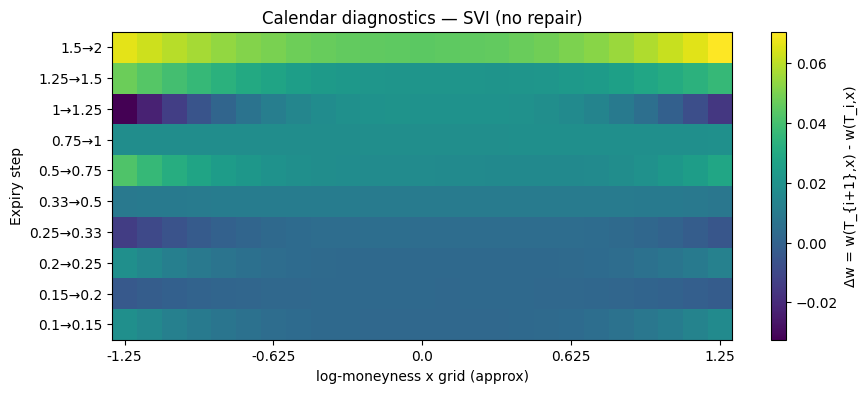

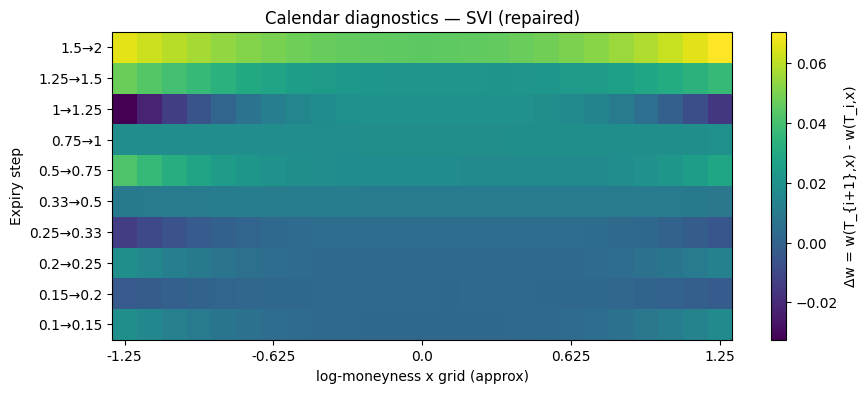

In [11]:
if demo.DEMO_PROFILE == "full":
    # Plot calendar diagnostics and violation structure if present
    vs_plot.plot_calendar_heatmap_from_report(
        surface_grid,
        art.reports["noarb_grid"],
        title="Calendar diagnostics — raw grid surface",
    )
    vs_plot.plot_calendar_heatmap_from_report(
        surface_svi_norepair,
        art.reports["noarb_svi_nr"],
        title="Calendar diagnostics — SVI (no repair)",
    )
    vs_plot.plot_calendar_heatmap_from_report(
        surface_svi_repaired,
        art.reports["noarb_svi_fx"],
        title="Calendar diagnostics — SVI (repaired)",
    )

=== First violation diagnostics: grid surface ===
No strike monotonicity violations found.


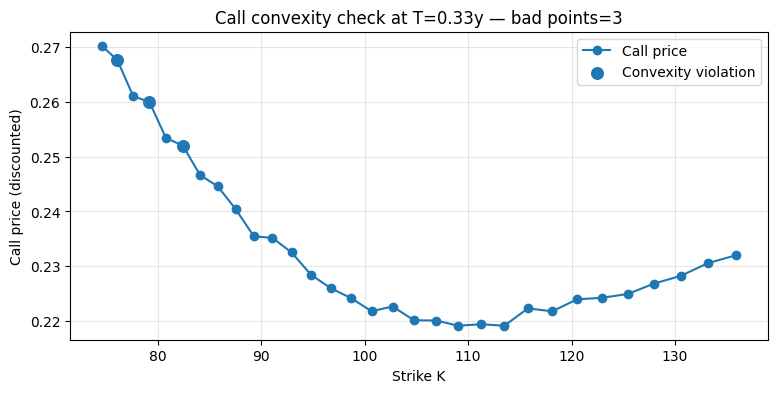

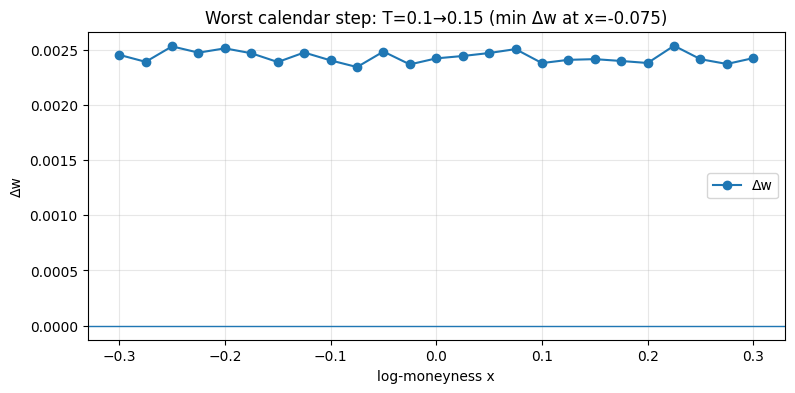

In [12]:
if demo.DEMO_PROFILE == "full":
    # Optional: inspect first detailed violations (very useful in interviews)
    print("=== First violation diagnostics: grid surface ===")
    vs_plot.plot_first_strike_monotonicity_violation(
        surface_grid,
        art.reports["noarb_grid"],
        forward=art.synthetic["forward"],
        df=art.synthetic["df_curve"],
    )
    vs_plot.plot_first_convexity_violation(
        surface_grid,
        art.reports["noarb_grid"],
        forward=art.synthetic["forward"],
        df=art.synthetic["df_curve"],
    )
    vs_plot.plot_worst_calendar_slice(surface_grid, art.reports["noarb_grid"])

## 3) SVI diagnostics + explicit repair showcase

**Intent:** make the SVI work visible: fit quality, residuals, and a “before/after” repair story.  
**Takeaway:** we don’t claim no-arb/robustness — we show the checks and the fix path.

<details>
<summary><b>Speaker notes (20–30s)</b></summary>

- “This is the ‘numerical judgment’ part: don’t just fit — validate.”
- “Repairs are used when the surface would otherwise be unsafe to differentiate.”

</details>


In [13]:
# Compare SVI fit quality tables (no-repair vs repaired)
svi_fit_compare = art.tables["svi_fit_compare"]

if demo.DEMO_PROFILE == "full":
    show_table("SVI fit comparison (no-repair vs repaired)", svi_fit_compare, max_rows=12)

# Pick a focus expiry (worst RMSE on no-repair if available)
focus_T = art.meta["focus_T"]
print("Focus expiry for SVI plots:", focus_T)

### SVI fit comparison (no-repair vs repaired)

,T,diag_ok_nr,rmse_w_nr,mae_w_nr,min_g_nr,butterfly_ok_nr,failure_reason_nr,diag_ok_fx,rmse_w_fx,mae_w_fx,min_g_fx,butterfly_ok_fx,failure_reason_fx
0,0.10,True,0.000093,0.000070,0.026640,True,,True,0.000093,0.000070,0.026640,True,
1,0.15,True,0.000115,0.000096,0.005219,True,,True,0.000115,0.000096,0.005226,True,
2,0.20,True,0.000114,0.000093,0.036877,True,,True,0.000114,0.000093,0.036883,True,
3,0.25,False,0.000134,0.000105,-0.000634,False,g_below_floor,False,0.000134,0.000105,-0.000635,False,g_below_floor
4,0.33,True,0.000169,0.000147,0.073815,True,,True,0.000169,0.000147,0.073822,True,
5,0.50,True,0.000222,0.000170,0.143934,True,,True,0.000222,0.000170,0.143941,True,
6,0.75,False,0.000340,0.000282,-0.000886,False,g_below_floor,False,0.000340,0.000282,-0.000888,False,g_below_floor
7,1.00,False,0.000446,0.000353,-0.015580,False,g_below_floor,False,0.000446,0.000353,-0.015581,False,g_below_floor
8,1.25,True,0.000684,0.000526,0.332356,True,,True,0.000684,0.000526,0.332356,True,
9,1.50,True,0.000642,0.000495,0.267266,True,,True,0.000642,0.000495,0.267264,True,


Focus expiry for SVI plots: 2.0


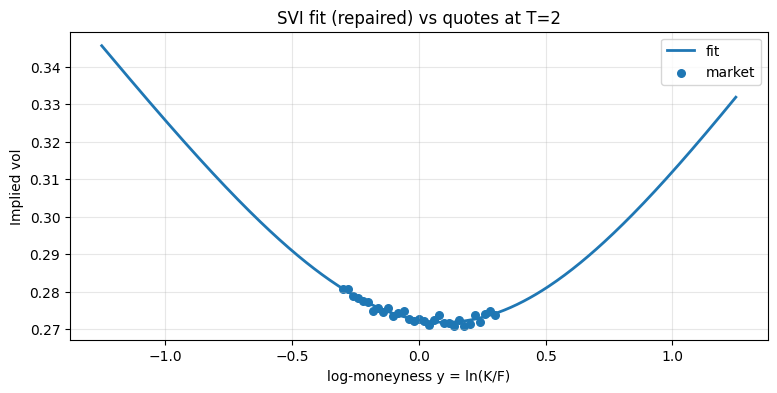

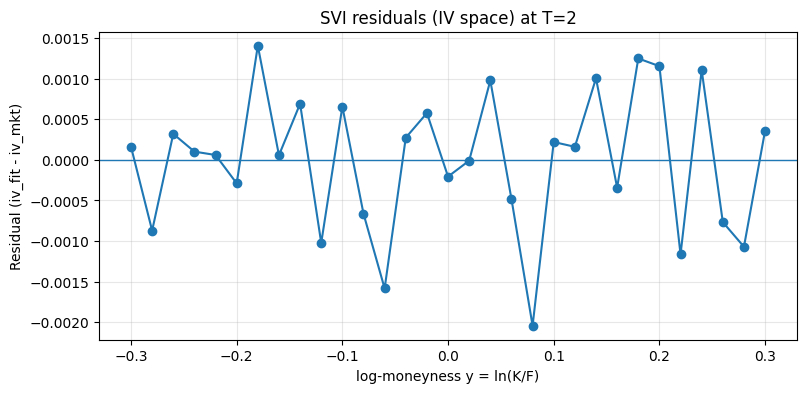

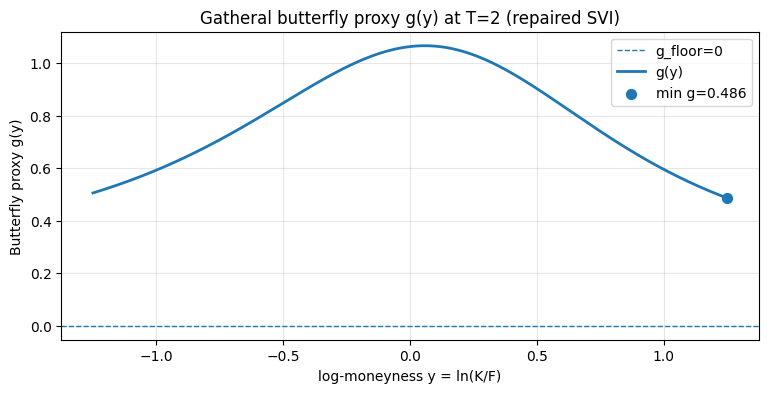

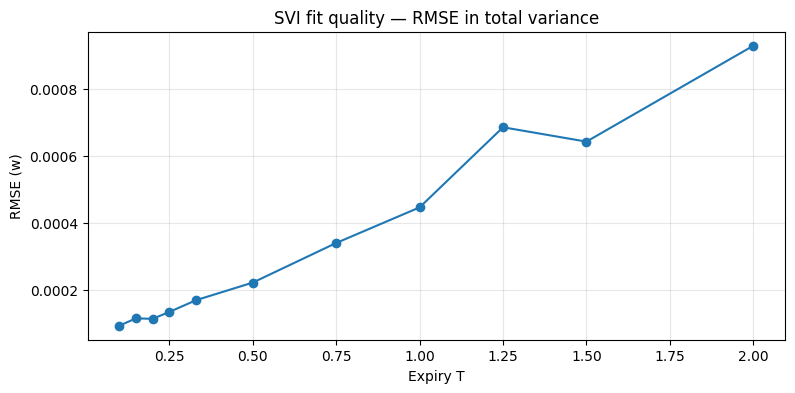

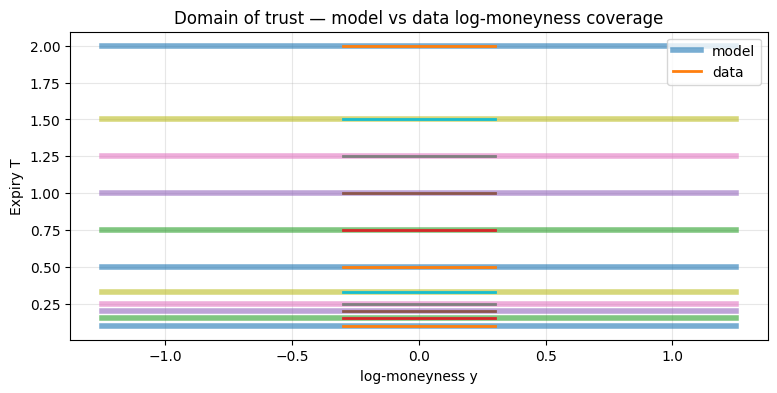

In [14]:
# Fit slice + residuals + butterfly proxy on the focus expiry
quotes_for_plots = quotes_df.rename(columns={"iv_obs": "iv"})[["T", "K", "iv"]]

vs_plot.plot_svi_fit_slice(
    surface_svi_repaired,
    T=focus_T,
    forward=art.synthetic["forward"],
    quotes_df=quotes_for_plots,
    kind="iv",
    title=f"SVI fit (repaired) vs quotes at T={focus_T:g}",
)

vs_plot.plot_svi_residuals(
    surface_svi_repaired,
    T=focus_T,
    forward=art.synthetic["forward"],
    quotes_df=quotes_for_plots,
    kind="iv",
    title=f"SVI residuals (IV space) at T={focus_T:g}",
)

vs_plot.plot_butterfly_proxy(
    surface_svi_repaired,
    T=focus_T,
    title=f"Gatheral butterfly proxy g(y) at T={focus_T:g} (repaired SVI)",
)

if demo.DEMO_PROFILE == "full":
    vs_plot.plot_svi_rmse_by_expiry(surface_svi_repaired)
    vs_plot.plot_surface_domain_report(
        surface_svi_repaired,
        quotes_df=quotes_for_plots,
        forward=art.synthetic["forward"],
    )

### Explicit bad-SVI demo metadata

,base_source,generator_source,good_ok,bad_ok,rho_abs,mode,b_base,b_bad,b_mult_eff,sigma_base,sigma_bad,sigma_mult_eff,b_wing_threshold,good_min_g,bad_min_g,bad_failure_reason,y_min,y_max,T
0,focus_slice_params,from_base_params,True,False,0.95,forced_wing,0.154309,1.046677,6.782982,1.204221,1.083799,0.9,1.026154,0.230113,-0.01036,"wing_limit_violation (gL_inf=0.25, gR_inf=-0.0...",-1.25,1.25,2.0


### Explicit SVI slice repair attempts

,method,ok,min_g,failure_reason,error
0,jw_optimal,True,-9.999968e-11,,


### Explicit SVI slice repair summary

,stage,ok,min_g,min_g_plot,argmin_plot,lee_ok,params,failure_reason
0,before_repair,False,-1.036017e-02,0.046145,1.25,False,"SVIParams(a=-0.03796155644103699, b=1.04667692...","wing_limit_violation (gL_inf=0.25, gR_inf=-0.0..."
1,after_repair,True,-9.999968e-11,0.146496,1.25,True,"SVIParams(a=-0.05311322764695281, b=0.88018504...",None


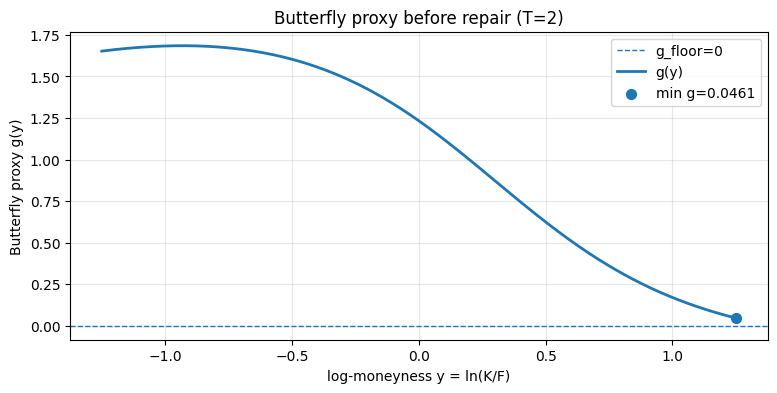

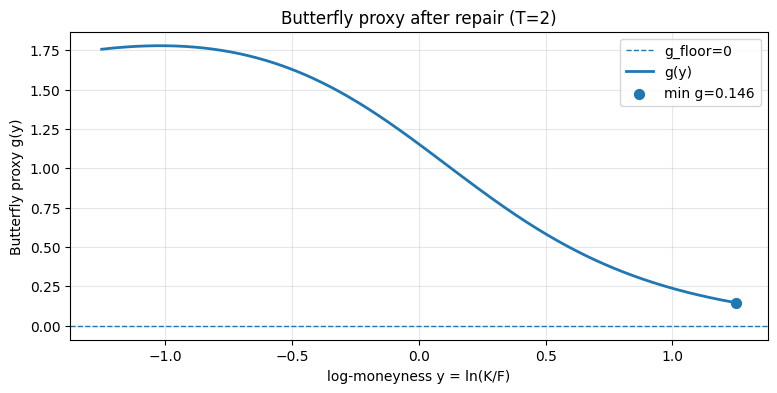

In [15]:
if art.flags["RUN_EXPLICIT_SVI_REPAIR_DEMO"]:
    # --- Explicit "SVI fixing" demo on one slice (before/after) ---
    explicit_repair_demo = art.reports["explicit_repair_demo"]

    show_table(
        "Explicit bad-SVI demo metadata",
        art.tables.get("explicit_repair_metadata"),
        max_rows=20,
    )
    show_table(
        "Explicit SVI slice repair attempts",
        art.tables.get("explicit_repair_attempts"),
        max_rows=10,
    )
    show_table(
        "Explicit SVI slice repair summary",
        art.tables.get("explicit_repair_summary"),
        max_rows=10,
    )

    vs_plot.plot_butterfly_proxy(
        explicit_repair_demo.smile_pre_plot,
        title=f"Butterfly proxy before repair (T={explicit_repair_demo.smile_pre_plot.T:g})",
    )
    vs_plot.plot_butterfly_proxy(
        explicit_repair_demo.smile_post_plot,
        title=f"Butterfly proxy after repair (T={explicit_repair_demo.smile_post_plot.T:g})",
    )

### GJ (2013) Example 5.1: computed vs paper

,quantity,computed,paper
0,JW.v,0.017426,0.017426
1,JW.psi,-0.175211,-0.175211
2,JW.p,0.699738,0.699738
3,JW.c,1.316798,1.316798
4,JW.v_tilde,0.011625,0.011625
5,Section 5.1 target c0,0.349316,0.349316
6,Section 5.1 target vtilde0,0.015482,0.015482
7,Projected c0 (actual),0.349316,0.349316
8,Projected vtilde0 (actual),0.015482,0.015482
9,Optimal c*,1.064430,0.856476


### GJ (2013) Example 5.1: butterfly checks

,stage,ok,min_g,failure_reason
0,orig,False,-3.286357e-02,g_below_floor
1,projected,True,2.534913e-01,None
2,optimal,True,-9.434344e-11,None


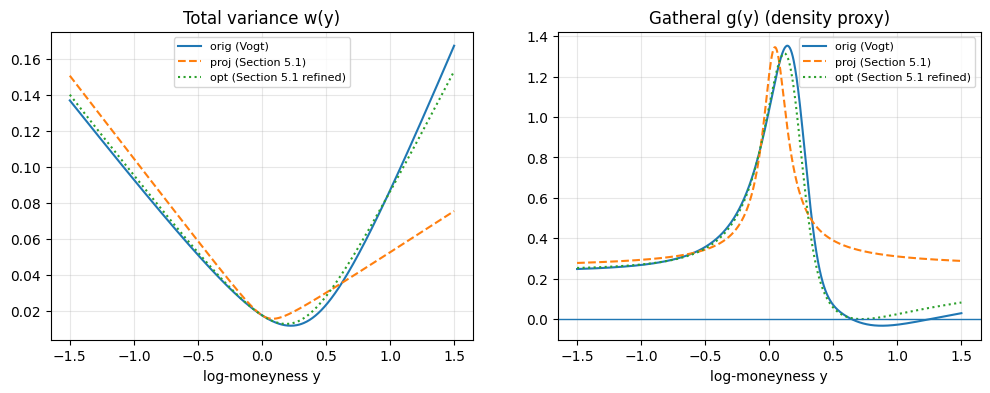

In [16]:
if demo.SHOW_ADVANCED and art.flags.get("RUN_GJ_EXAMPLE51_SANITY_CHECK", True):
    # --- Gatheral-Jacquier (2013) Example 5.1: smile repair sanity check ---
    # This now delegates the paper-example orchestration to the library diagnostics helper.

    if art.flags["RUN_GJ_EXAMPLE51"]:
        import matplotlib.pyplot as plt

        gj51 = art.gj51

        show_table(
            "GJ (2013) Example 5.1: computed vs paper",
            art.tables.get("gj51_comparison"),
            max_rows=20,
        )
        show_table(
            "GJ (2013) Example 5.1: butterfly checks",
            art.tables.get("gj51_checks"),
            max_rows=10,
        )

        fig, ax = plt.subplots(1, 2, figsize=(12, 4))

        ax[0].plot(gj51.y_plot, gj51.w_raw, label="orig (Vogt)")
        ax[0].plot(gj51.y_plot, gj51.w_projected, linestyle="--", label="proj (Section 5.1)")
        ax[0].plot(gj51.y_plot, gj51.w_optimal, linestyle=":", label="opt (Section 5.1 refined)")
        ax[0].set_title("Total variance w(y)")
        ax[0].set_xlabel("log-moneyness y")
        ax[0].grid(True, alpha=0.3)
        ax[0].legend(fontsize=8)

        ax[1].plot(gj51.y_plot, gj51.g_raw, label="orig (Vogt)")
        ax[1].plot(gj51.y_plot, gj51.g_projected, linestyle="--", label="proj (Section 5.1)")
        ax[1].plot(gj51.y_plot, gj51.g_optimal, linestyle=":", label="opt (Section 5.1 refined)")
        ax[1].axhline(0.0, linewidth=1.0)
        ax[1].set_title("Gatheral g(y) (density proxy)")
        ax[1].set_xlabel("log-moneyness y")
        ax[1].grid(True, alpha=0.3)
        ax[1].legend(fontsize=8)

        plt.show()


## 4) Interpolation choice demo (`no_arb` vs `linear_w`) — optional deep dive

This section is **full-mode only**. It exists to explain why the library exposes two slice methods:
- `no_arb`: quote-facing interpolation that tries to respect constraints
- `linear_w`: smoother total-variance interpolation (useful when you need differentiability)



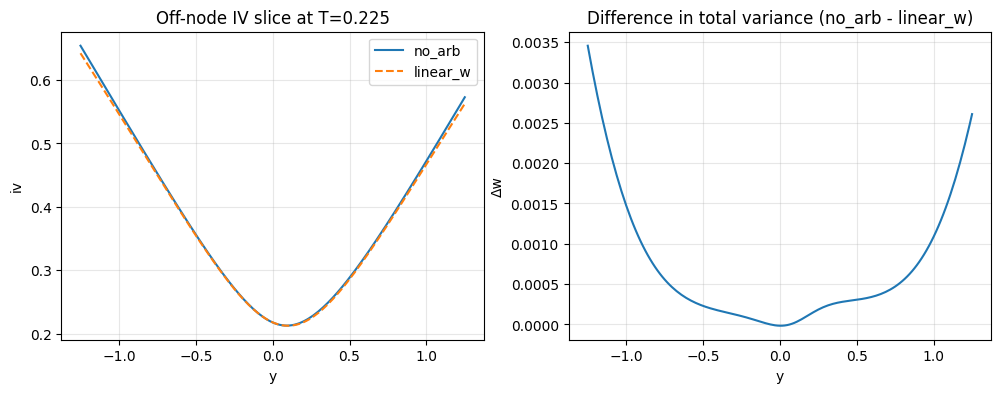

In [17]:
if demo.DEMO_PROFILE == "full":
    import matplotlib.pyplot as plt
    import numpy as np

    # Compare off-node slices under the two interpolation modes at one intermediate maturity
    expiries = np.asarray(surface_svi_repaired.expiries, dtype=float)
    T_mid = float(0.5 * (expiries[2] + expiries[3]))  # between two nodes
    s_noarb = surface_svi_repaired.slice(T_mid, method="no_arb")
    s_linw = surface_svi_repaired.slice(T_mid, method="linear_w")

    yq = np.linspace(
        max(float(s_noarb.y_min), float(s_linw.y_min)),
        min(float(s_noarb.y_max), float(s_linw.y_max)),
        161,
    )

    iv_noarb = np.asarray(s_noarb.iv_at(yq), dtype=float)
    iv_linw = np.asarray(s_linw.iv_at(yq), dtype=float)
    w_noarb = np.asarray(s_noarb.w_at(yq), dtype=float)
    w_linw = np.asarray(s_linw.w_at(yq), dtype=float)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(yq, iv_noarb, label="no_arb")
    axes[0].plot(yq, iv_linw, label="linear_w", linestyle="--")
    axes[0].set_title(f"Off-node IV slice at T={T_mid:g}")
    axes[0].set_xlabel("y")
    axes[0].set_ylabel("iv")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(yq, w_noarb - w_linw)
    axes[1].set_title("Difference in total variance (no_arb - linear_w)")
    axes[1].set_xlabel("y")
    axes[1].set_ylabel("Δw")
    axes[1].grid(True, alpha=0.3)

    plt.show()

## 5) Local vol from the repaired surface + diagnostics

**Key differentiator:** treat local vol as a **diagnostic object first**, pricing input second.

We highlight:
- invalid masks / reason codes
- denominator / stability diagnostics
- where the surface should *not* be trusted blindly

<details>
<summary><b>Speaker notes (20–30s)</b></summary>

- “Dupire/local vol uses derivatives — so diagnostics come first.”
- “The project makes failure modes visible instead of hiding them.”

</details>


In [18]:
localvol = art.localvol
lv_rep = art.reports["lv_rep"]

show_table(
    "Local-vol diagnostics summary",
    art.tables["localvol_summary"],
    max_rows=10,
)

if demo.DEMO_PROFILE == "full":
    show_table("Invalid reason counts", art.tables["localvol_reason_counts"], max_rows=15)
    show_table(
        "Worst denominator points / suspect locations",
        art.tables["localvol_worst_points"],
        max_rows=12,
)

### Local-vol diagnostics summary

,invalid_count,invalid_frac,sigma_min,sigma_median,sigma_max,denom_abs_min
0,0,0.0,0.2106,0.284216,0.400779,0.313308


### Invalid reason counts

""


### Worst denominator points / suspect locations

,rank,T,y,K,denom,local_var,sigma,invalid,reasons
0,1,0.12,-0.30,74.259832,0.313308,0.160624,0.400779,False,
1,2,0.12,-0.29,75.006156,0.326739,0.153024,0.391183,False,
2,3,0.12,-0.28,75.759980,0.340950,0.145791,0.381826,False,
3,4,0.12,0.30,135.310236,0.347191,0.139114,0.372980,False,
4,5,0.12,-0.27,76.521381,0.355981,0.138907,0.372702,False,
5,6,0.12,-0.26,77.290433,0.371873,0.132357,0.363809,False,
6,7,0.12,0.29,133.963877,0.374222,0.128895,0.359019,False,
7,8,0.12,-0.25,78.067215,0.388664,0.126126,0.355142,False,
8,9,0.12,0.28,132.630914,0.403059,0.119560,0.345775,False,
9,10,0.12,-0.24,78.851804,0.406392,0.120201,0.346700,False,


_Showing first 12 of 15 rows. Toggle `Verbose tables` to show full tables._

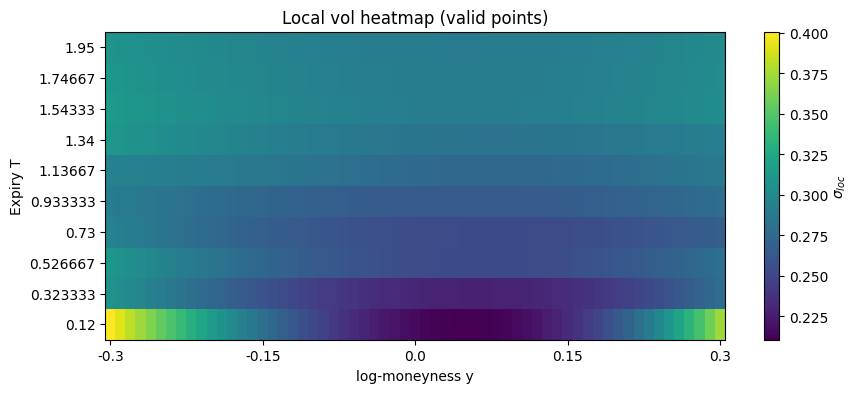

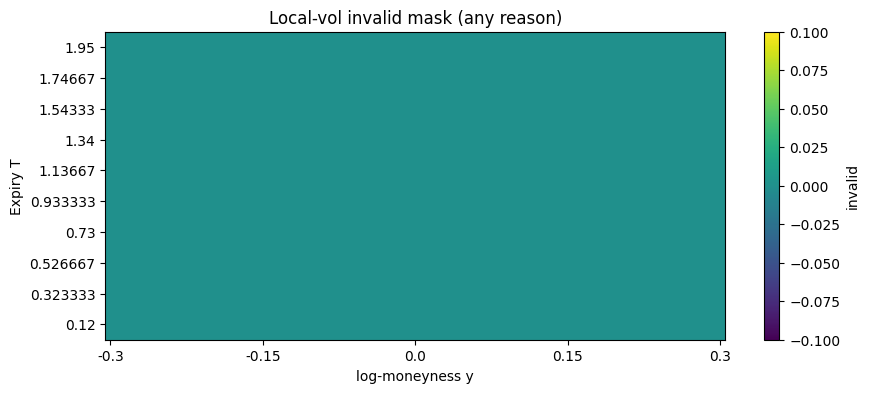

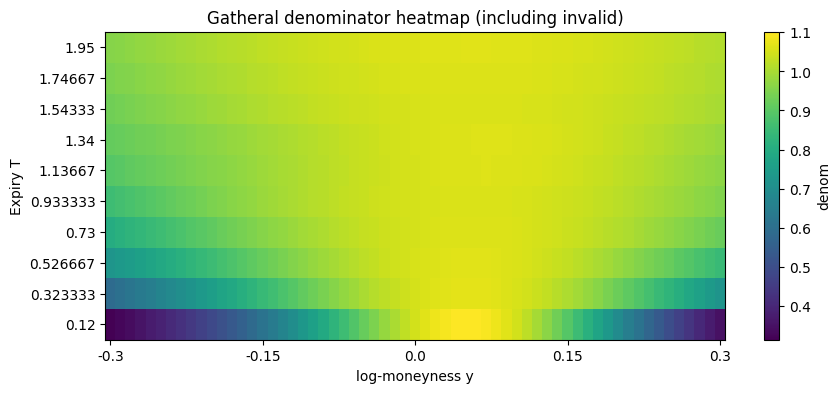

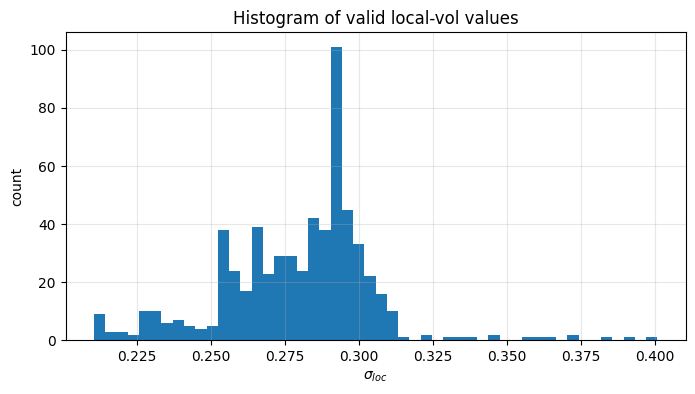

In [19]:
vs_plot.plot_localvol_heatmap(lv_rep, kind="sigma", title="Local vol heatmap (valid points)")
vs_plot.plot_localvol_invalid_mask(lv_rep, title="Local-vol invalid mask (any reason)")

if demo.DEMO_PROFILE == "full":
    vs_plot.plot_localvol_heatmap(
        lv_rep,
        kind="denom",
        mask_invalid=False,
        title="Gatheral denominator heatmap (including invalid)",
    )
    vs_plot.plot_localvol_histogram(lv_rep, title="Histogram of valid local-vol values")

### Gatheral vs Dupire local-vol comparison summary

,n_total,n_compared,compared_frac,gatheral_invalid_frac,dupire_invalid_frac,union_invalid_frac,diff_sigma_rmse,diff_sigma_mae,diff_sigma_max_abs
0,341,261,0.765396,0.0,0.234604,0.234604,0.004417,0.003782,0.017359


### Worst local-vol disagreements (Dupire - Gatheral)

,rank,T,K,y,sigma_gatheral,sigma_dupire,diff_sigma,denom_gatheral,denom_dupire
0,1,0.15,128.166667,0.245161,0.281434,0.298794,0.017359,0.607933,5.776803
1,2,0.15,126.333333,0.230754,0.270725,0.283432,0.012708,0.657348,8.989610
2,3,1.25,76.833333,-0.288532,0.292201,0.301672,0.009471,0.912472,65.385827
3,4,0.15,124.500000,0.216136,0.260893,0.269362,0.008469,0.708496,14.020336
4,5,0.50,98.833333,-0.021735,0.241018,0.249402,0.008384,1.041673,246.577828
5,6,0.50,100.666667,-0.003355,0.239709,0.248067,0.008358,1.052137,254.630264
6,7,0.50,97.000000,-0.040459,0.242698,0.250962,0.008263,1.028403,234.898640
7,8,0.50,102.500000,0.014693,0.238759,0.246944,0.008185,1.059762,258.774533
8,9,0.50,95.166667,-0.059540,0.244761,0.252767,0.008005,1.012404,220.070023
9,10,1.25,78.666667,-0.264951,0.292009,0.300010,0.008002,0.923683,72.110451


### Invalid reason counts (Gatheral)

""
0


### Invalid reason counts (Dupire)

,LOCALVAR_NEGATIVE,TRIM_T,TRIM_K
0,3,62,22


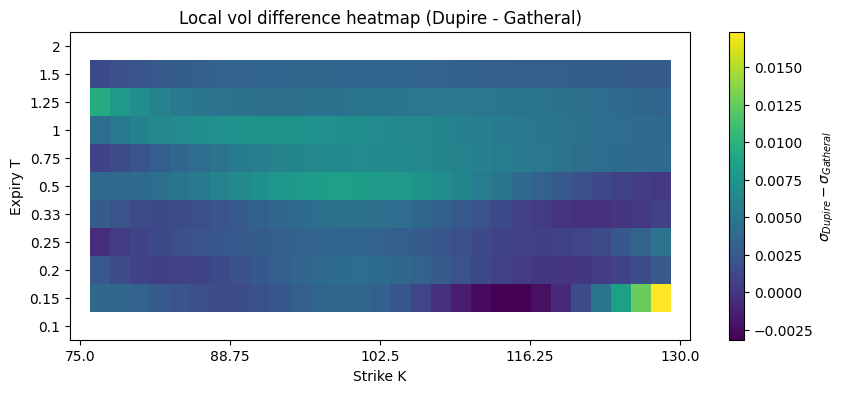

In [20]:
# Optional: compare Gatheral-from-w local vol vs Dupire-from-call-grid on a shared strike grid
if art.flags["RUN_DUPIRE_VS_GATHERAL_COMPARE"]:
    lv_cmp = art.reports["lv_compare"]

    show_table(
        "Gatheral vs Dupire local-vol comparison summary",
        art.tables["lv_compare_summary"],
        max_rows=10,
    )

    show_table(
        "Worst local-vol disagreements (Dupire - Gatheral)",
        art.tables["lv_compare_worst_diffs"],
        max_rows=12,
    )

    show_table(
        "Invalid reason counts (Gatheral)",
        art.tables["lv_compare_gatheral_reasons"],
        max_rows=10,
    )

    show_table(
        "Invalid reason counts (Dupire)",
        art.tables["lv_compare_dupire_reasons"],
        max_rows=10,
    )

    vs_plot.plot_localvol_method_diff(
        lv_cmp,
        kind="sigma",
        title="Local vol difference heatmap (Dupire - Gatheral)",
    )

## 6) PDE diagnostics baseline — convergence + stability evidence (full-mode)

This section is **full-mode only**. It benchmarks the PDE stack against a case with an analytic reference and shows convergence / remedies for difficult payoffs.

<details>
<summary><b>Speaker notes (15–25s)</b></summary>

- “The PDE stack is not just present — it’s benchmarked where we know the answer.”
- “Refinement trends and payoff remedies build credibility.”

</details>


### Digital PDE sweep (OK runs)

,contract,kind,payout,tau,spot,strike,sigma,r,q,sweep,...,pde,err,abs_err,rel_err,x0,feasible,within_budget,feasible_and_within_budget,score,domain_n_sigma
0,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000003,0.000003,0.000006,4.60517,True,True,True,44.0120,4.0
1,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000003,0.000003,0.000006,4.60517,True,True,True,73.7103,4.0
2,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000003,0.000003,0.000006,4.60517,True,True,True,147.4859,4.0
3,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000002,0.000002,0.000005,4.60517,True,True,True,62.2944,4.0
4,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000002,0.000002,0.000005,4.60517,True,True,True,119.8647,4.0
5,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000002,0.000002,0.000005,4.60517,True,False,False,NaN,4.0
6,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482636,0.000001,0.000001,0.000003,4.60517,True,True,True,65.2029,4.0
7,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482636,0.000001,0.000001,0.000003,4.60517,True,True,True,113.0220,4.0
8,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482636,0.000001,0.000001,0.000003,4.60517,True,True,True,217.6584,4.0
9,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000002,0.000002,0.000004,4.60517,True,True,True,38.4239,5.0


_Showing first 12 of 72 rows. Toggle `Verbose tables` to show full tables._

### Grouped summary (mean error/runtime by method/advection/grid)

,method,advection,Nx,Nt,n,abs_err_mean,abs_err_max,runtime_ms_mean,feasible_rate
0,rannacher,upwind,201,101,2,0.000001,0.000001,58.34750,1.0
1,rannacher,upwind,201,201,2,0.000001,0.000001,109.35555,1.0
2,rannacher,upwind,201,401,2,0.000001,0.000001,254.09230,0.5
3,cn,upwind,201,401,2,0.000001,0.000001,230.20105,1.0
4,cn,upwind,201,201,2,0.000001,0.000001,119.09345,1.0
5,cn,upwind,201,101,2,0.000001,0.000002,62.16520,1.0
6,cn,central,201,101,2,0.000002,0.000002,63.74095,1.0
7,cn,central,201,201,2,0.000002,0.000002,111.72265,1.0
8,cn,central,201,401,2,0.000002,0.000002,227.73125,1.0
9,rannacher,central,201,401,2,0.000002,0.000002,209.94820,1.0


_Showing first 12 of 36 rows. Toggle `Verbose tables` to show full tables._

### Pareto frontier (runtime vs abs error)

,contract,kind,payout,tau,spot,strike,sigma,r,q,sweep,...,pde,err,abs_err,rel_err,x0,feasible,within_budget,feasible_and_within_budget,score,domain_n_sigma
0,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482637,0.000002,0.000002,0.000004,4.60517,True,True,True,38.4239,5.0
1,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482633,-0.000002,0.000002,0.000003,4.60517,True,True,True,48.1989,4.0
2,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482633,-0.000001,0.000001,0.000003,4.60517,True,True,True,55.8187,5.0
3,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482633,-0.000001,0.000001,0.000003,4.60517,True,True,True,56.1471,4.0
4,digital,call,1.0,1.0,100.0,100.0,0.22,0.02,0.0,NxNt,...,0.482633,-0.000001,0.000001,0.000003,4.60517,True,True,True,60.8763,4.0


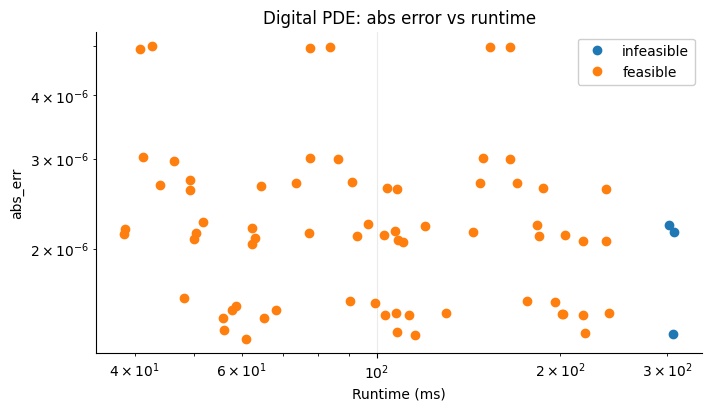

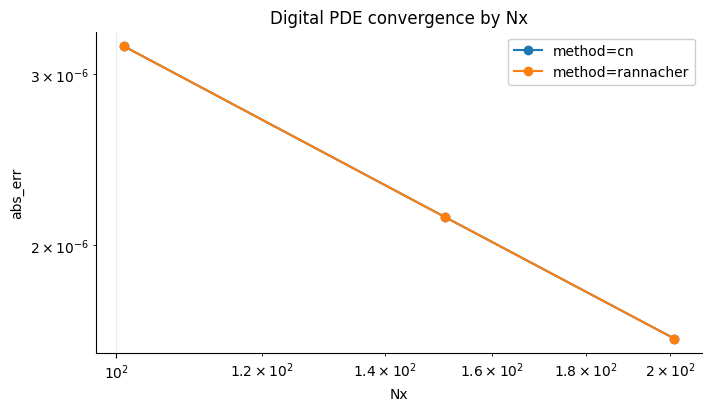

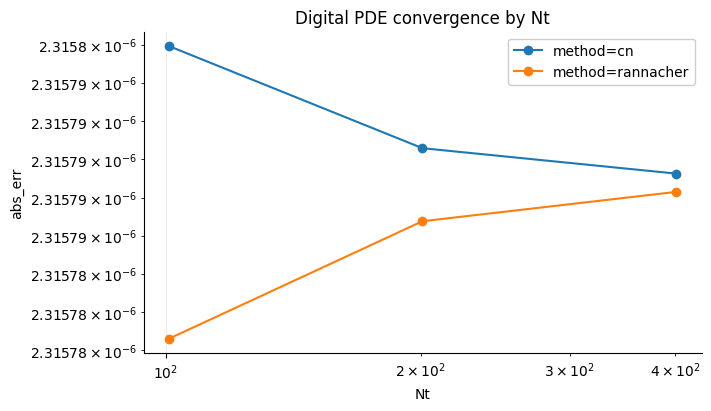

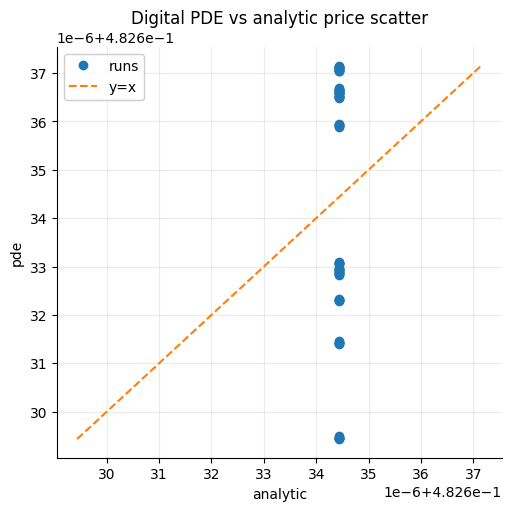

In [21]:
if art.flags["RUN_DIGITAL_PDE_BASELINE"]:
    from option_pricing.diagnostics.pde import plots as pde_plot

    digital_baseline = art.digital_baseline

    show_table("Digital PDE sweep (OK runs)", art.tables["digital_ok"], max_rows=12)

    if not art.tables["digital_errors"].empty:
        show_table("Failed runs (if any)", art.tables["digital_errors"], max_rows=12)

    show_table(
        "Grouped summary (mean error/runtime by method/advection/grid)",
        art.tables["digital_grouped"],
        max_rows=12,
    )
    show_table(
        "Pareto frontier (runtime vs abs error)",
        art.tables["digital_frontier"],
        max_rows=12,
    )

    pde_plot.plot_error_vs_runtime(
        digital_baseline.ok,
        title="Digital PDE: abs error vs runtime",
    )
    pde_plot.plot_convergence(
        digital_baseline.ok,
        x_col="Nx",
        y_col="abs_err",
        group_col="method",
        title="Digital PDE convergence by Nx",
    )
    pde_plot.plot_convergence(
        digital_baseline.ok,
        x_col="Nt",
        y_col="abs_err",
        group_col="method",
        title="Digital PDE convergence by Nt",
    )
    pde_plot.plot_price_scatter(
        digital_baseline.ok,
        x_col="analytic",
        y_col="pde",
        title="Digital PDE vs analytic price scatter",
    )

## 7) End-to-end local-vol PDE repricing checks (vanillas)

**Goal:** close the loop: use the surface as “market”, build local vol, reprice vanillas under the PDE, and check consistency.

<details>
<summary><b>Speaker notes (15–25s)</b></summary>

- “This is the end-to-end proof: surface → local vol → PDE → repricing sanity checks.”
- “If something is off, the earlier diagnostics tell you *where* and *why*.”

</details>


### Local-vol PDE repricing table

,T,K,target_iv,target_price,pde_price,abs_price_error,pde_iv,abs_iv_error_bp,iv_ok,iv_error,runtime_ms,Nx,Nt
0,0.1,78.666667,0.313309,21.511512,21.496944,0.014569,0.275913,373.955084,True,,273.0556,201,401
1,0.1,82.333333,0.289441,17.878392,17.852726,0.025667,0.260891,285.506397,True,,283.0335,201,401
2,0.1,86.000000,0.267843,14.282566,14.243891,0.038675,0.248793,190.506309,True,,298.8603,201,401
3,0.1,89.666667,0.248747,10.778046,10.733649,0.044397,0.238207,105.401774,True,,324.2776,201,401
4,0.1,93.333333,0.232401,7.483092,7.459462,0.023630,0.229285,31.162856,True,,368.4008,201,401
5,0.1,97.000000,0.219049,4.608683,4.643401,0.034718,0.222168,31.186531,True,,379.5323,201,401
6,0.1,100.666667,0.208891,2.414703,2.517132,0.102429,0.217015,81.242751,True,,297.6504,201,401
7,0.1,104.333333,0.202037,1.042099,1.169175,0.127076,0.213967,119.308937,True,,519.2738,201,401
8,0.1,108.000000,0.198471,0.369679,0.467892,0.098213,0.213047,145.754840,True,,301.7056,201,401
9,0.1,111.666667,0.198033,0.112253,0.166575,0.054322,0.214275,162.423789,True,,310.5911,201,401


_Showing first 12 of 154 rows. Toggle `Verbose tables` to show full tables._

### Repricing summary

,n_options,mean_abs_price_error,max_abs_price_error,mean_abs_iv_error_bp,max_abs_iv_error_bp,mean_runtime_ms,total_runtime_ms,Nx,Nt
0,154,0.144547,0.670255,80.783232,373.955084,315.90734,49054.7174,201,401


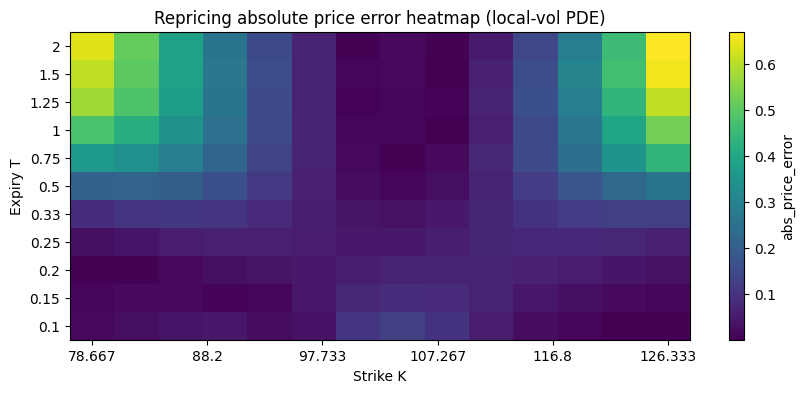

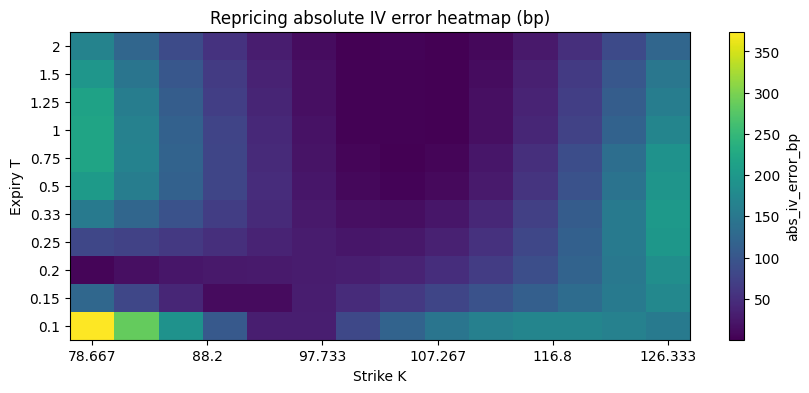

In [22]:
if art.flags["RUN_LOCALVOL_REPRICING"] and art.repricing is not None:
    repricing_res = art.repricing

    show_table("Local-vol PDE repricing table", repricing_res.grid, max_rows=12)
    show_table("Repricing summary", repricing_res.summary, max_rows=10)

    vs_plot.plot_repricing_heatmap(
        repricing_res.grid,
        value_col="abs_price_error",
        title="Repricing absolute price error heatmap (local-vol PDE)",
    )
    vs_plot.plot_repricing_heatmap(
        repricing_res.grid,
        value_col="abs_iv_error_bp",
        title="Repricing absolute IV error heatmap (bp)",
    )

### Local-vol PDE convergence sweep (single option)

,Nx,Nt,grid_points,pde_price,target_price,abs_error,runtime_ms
0,101,201,20301,9.926076,9.931446,0.005370,144.4348
1,151,301,45451,9.928495,9.931446,0.002951,220.8148
2,201,401,80601,9.928655,9.931446,0.002792,290.8546
3,251,501,125751,9.928913,9.931446,0.002533,411.4097


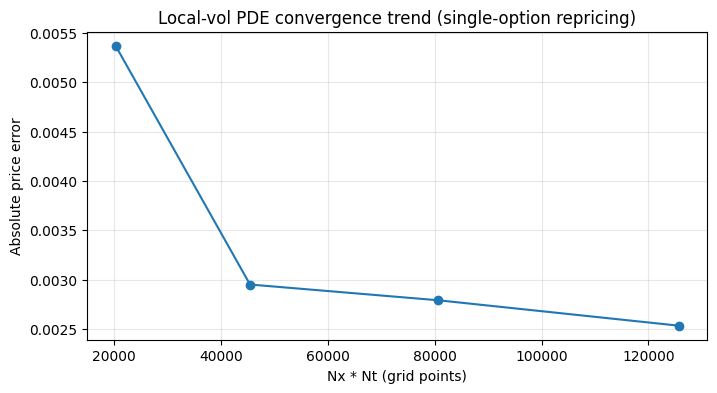

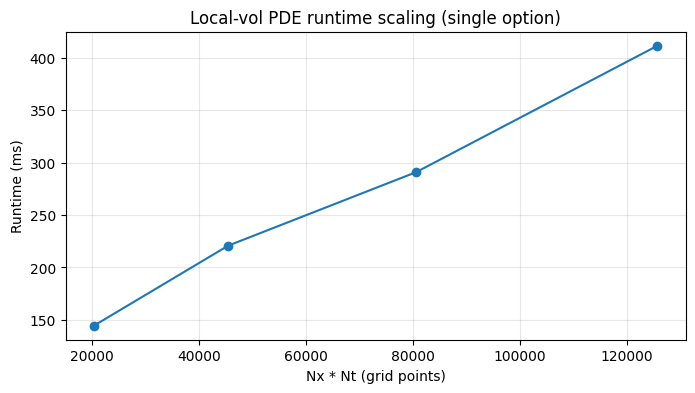

In [23]:
if art.flags["RUN_LOCALVOL_CONVERGENCE_SWEEP"] and art.convergence is not None:
    import matplotlib.pyplot as plt

    conv_df = art.convergence.grid
    show_table("Local-vol PDE convergence sweep (single option)", conv_df, max_rows=12)

    plt.figure(figsize=(8, 4))
    plt.plot(conv_df["grid_points"], conv_df["abs_error"], marker="o")
    plt.xlabel("Nx * Nt (grid points)")
    plt.ylabel("Absolute price error")
    plt.title("Local-vol PDE convergence trend (single-option repricing)")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(conv_df["grid_points"], conv_df["runtime_ms"], marker="o")
    plt.xlabel("Nx * Nt (grid points)")
    plt.ylabel("Runtime (ms)")
    plt.title("Local-vol PDE runtime scaling (single option)")
    plt.grid(True, alpha=0.3)
    plt.show()

## 8) Wrap-up (minimal) + links

Controlled claim:

> This is a **portfolio-grade / research-grade** local-vol + PDE workflow: strong on validation and numerical transparency, with the next step being stronger real-data calibration and interpolation choices.

For a longer talk track / Q&A prompts, see: `docs/user_guides/flagship_capstone2_page.md`.

<details>
<summary><b>Optional speaker notes / Q&A (expand)</b></summary>

- What makes this better than a typical student project?
  - “Most stop at implementing a model. Here the emphasis is numerical judgment: repair-aware surface construction, explicit diagnostics, PDE benchmarking, and convergence evidence.”
- What would you do next?
  - “Highest value: real-data surface workflow, or a calibration-heavy model like Heston — extending the same validation discipline.”

</details>
